# Week 4 — Machine Learning Model
### Dataset: Titanic Passenger Survival

**Goal:** Prepare and preprocess the Titanic dataset, train a classification model to predict survival,
evaluate it with appropriate metrics, and critically discuss its errors, limitations, and possible
improvements.

Run top-to-bottom in **Google Colab**.


## 1. Setup & Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, ConfusionMatrixDisplay, roc_curve, roc_auc_score,
                              classification_report, RocCurveDisplay)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.max_columns", None)
np.random.seed(42)


In [2]:
from google.colab import files
import pandas as pd

uploaded = files.upload()

train_file = [f for f in uploaded if 'train' in f.lower()][0]
train = pd.read_csv(train_file)

test_files = [f for f in uploaded if 'test' in f.lower()]

if test_files:
    test = pd.read_csv(test_files[0])
else:
    test = None

print("Train:", train.shape)
print("Test:", test.shape if test is not None else "Not provided")
train.head()

Saving train.csv to train.csv
Saving test.csv to test.csv
Train: (891, 12)
Test: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Data Preparation & Preprocessing

In [3]:
# 2.1 Missing value handling (same rationale as Week 1)
train['Age'] = train.groupby(['Pclass', 'Sex'])['Age'].transform(lambda x: x.fillna(x.median()))
train['Embarked'] = train['Embarked'].fillna(train['Embarked'].mode()[0])
train['Has_Cabin'] = train['Cabin'].notnull().astype(int)

# 2.2 Feature engineering
train['FamilySize'] = train['SibSp'] + train['Parch'] + 1
train['IsAlone'] = (train['FamilySize'] == 1).astype(int)
train['Title'] = train['Name'].str.extract(r',\s*([^\.]*)\s*\.')
title_map = {
    'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs',
    'Lady': 'Rare', 'Countess': 'Rare', 'Capt': 'Rare', 'Col': 'Rare',
    'Don': 'Rare', 'Dr': 'Rare', 'Major': 'Rare', 'Rev': 'Rare',
    'Sir': 'Rare', 'Jonkheer': 'Rare', 'Dona': 'Rare'
}
train['Title'] = train['Title'].replace(title_map)
train.loc[~train['Title'].isin(['Mr', 'Mrs', 'Miss', 'Master', 'Rare']), 'Title'] = 'Rare'

train[['FamilySize', 'IsAlone', 'Title', 'Has_Cabin']].head()


,FamilySize,IsAlone,Title,Has_Cabin
0,2,0,Mr,0
1,2,0,Mrs,1
2,1,1,Miss,0
3,2,0,Mrs,1
4,1,1,Mr,0


**Why these features?** `FamilySize`/`IsAlone` and `Title` proved to have clear relationships with
survival in Weeks 2-3 (small families and higher-status titles like "Master"/"Mrs" survived more often).
Feeding this domain knowledge into the model as explicit features (rather than relying on the model to
discover it from raw `SibSp`/`Parch`/`Name`) generally improves a simple model's performance.

In [4]:
# 2.3 Select final feature set and target
features = ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'Has_Cabin', 'Title']
target = 'Survived'

X = train[features]
y = train[target]

numeric_features = ['Age', 'Fare', 'FamilySize']
categorical_features = ['Pclass', 'Sex', 'Embarked', 'IsAlone', 'Has_Cabin', 'Title']

print(X.dtypes)


Pclass          int64
Sex            object
Age           float64
Fare          float64
Embarked       object
FamilySize      int64
IsAlone         int64
Has_Cabin       int64
Title          object
dtype: object


**Why scale numeric features and one-hot encode categoricals?** Logistic Regression is
sensitive to feature scale (it uses a weighted linear combination, and gradient-based optimization
converges better on standardized inputs). Categorical columns like `Pclass`, `Sex`, `Embarked`, and
`Title` have no inherent numeric order, so one-hot encoding avoids implying a false ordinal
relationship (e.g. treating "Southampton" > "Cherbourg" numerically, which would be meaningless).


In [5]:
# 2.4 Preprocessing pipeline
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])


In [6]:
# 2.5 Train/test split (stratified to preserve the ~38%/62% survival balance in both sets)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train size: {X_train.shape[0]}, Test size: {X_test.shape[0]}")
print(f"Train survival rate: {y_train.mean():.2%}, Test survival rate: {y_test.mean():.2%}")


Train size: 712, Test size: 179
Train survival rate: 38.34%, Test survival rate: 38.55%


## 3. Model Selection & Training

We'll train and compare two models:

1. **Logistic Regression** — a simple, highly interpretable baseline well-suited to a binary
   classification problem like this one.
2. **Random Forest** — a more flexible, non-linear ensemble model, to see if it captures interaction
   effects (e.g. Sex × Pclass) that logistic regression's linear boundary might miss.


In [7]:
# 3.1 Logistic Regression pipeline
logreg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=42))
])

logreg_pipeline.fit(X_train, y_train)
y_pred_logreg = logreg_pipeline.predict(X_test)
y_proba_logreg = logreg_pipeline.predict_proba(X_test)[:, 1]

print("Logistic Regression trained.")


Logistic Regression trained.


In [8]:
# 3.2 Random Forest pipeline
rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=300, max_depth=5, random_state=42))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print("Random Forest trained.")


Random Forest trained.


In [9]:
# 3.3 5-fold cross-validation on the training set (sanity check for stability, not just a single split)
cv_scores_logreg = cross_val_score(logreg_pipeline, X_train, y_train, cv=5, scoring='accuracy')
cv_scores_rf = cross_val_score(rf_pipeline, X_train, y_train, cv=5, scoring='accuracy')

print(f"Logistic Regression CV accuracy: {cv_scores_logreg.mean():.3f} +/- {cv_scores_logreg.std():.3f}")
print(f"Random Forest CV accuracy:       {cv_scores_rf.mean():.3f} +/- {cv_scores_rf.std():.3f}")


Logistic Regression CV accuracy: 0.825 +/- 0.020
Random Forest CV accuracy:       0.824 +/- 0.018


## 4. Model Evaluation

In [10]:
def evaluate(name, y_true, y_pred, y_proba):
    print(f"--- {name} ---")
    print(f"Accuracy:  {accuracy_score(y_true, y_pred):.3f}")
    print(f"Precision: {precision_score(y_true, y_pred):.3f}")
    print(f"Recall:    {recall_score(y_true, y_pred):.3f}")
    print(f"F1-score:  {f1_score(y_true, y_pred):.3f}")
    print(f"ROC-AUC:   {roc_auc_score(y_true, y_proba):.3f}")
    print()
    print(classification_report(y_true, y_pred, target_names=['Did not survive', 'Survived']))

evaluate("Logistic Regression", y_test, y_pred_logreg, y_proba_logreg)
evaluate("Random Forest", y_test, y_pred_rf, y_proba_rf)


--- Logistic Regression ---
Accuracy:  0.838
Precision: 0.803
Recall:    0.768
F1-score:  0.785
ROC-AUC:   0.869

                 precision    recall  f1-score   support

Did not survive       0.86      0.88      0.87       110
       Survived       0.80      0.77      0.79        69

       accuracy                           0.84       179
      macro avg       0.83      0.82      0.83       179
   weighted avg       0.84      0.84      0.84       179

--- Random Forest ---
Accuracy:  0.810
Precision: 0.787
Recall:    0.696
F1-score:  0.738
ROC-AUC:   0.848

                 precision    recall  f1-score   support

Did not survive       0.82      0.88      0.85       110
       Survived       0.79      0.70      0.74        69

       accuracy                           0.81       179
      macro avg       0.80      0.79      0.79       179
   weighted avg       0.81      0.81      0.81       179



**Metric choices & why they matter here:** Accuracy alone can be misleading on an imbalanced-ish
target (~38% survived). **Precision** tells us: of everyone we predicted survived, how many actually did
(costly to get wrong if, say, we were allocating limited lifeboats). **Recall** tells us: of everyone
who actually survived, how many did we correctly identify (costly to miss if we were trying to find
survivors). **F1** balances the two, and **ROC-AUC** summarizes ranking quality across all
classification thresholds, independent of any single cutoff.

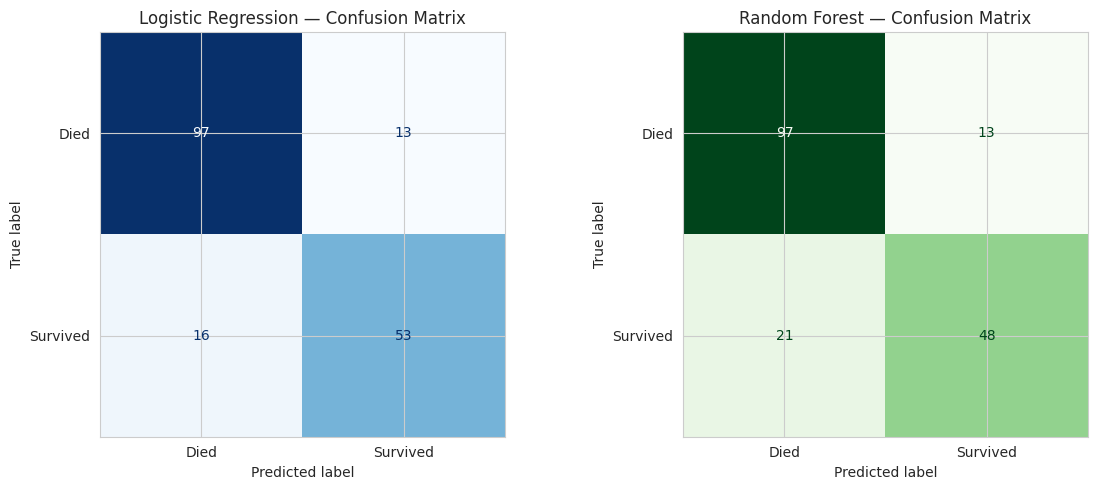

In [11]:
# Visualization 1: Confusion matrices side-by-side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_logreg = confusion_matrix(y_test, y_pred_logreg)
ConfusionMatrixDisplay(cm_logreg, display_labels=['Died', 'Survived']).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title("Logistic Regression — Confusion Matrix")

cm_rf = confusion_matrix(y_test, y_pred_rf)
ConfusionMatrixDisplay(cm_rf, display_labels=['Died', 'Survived']).plot(ax=axes[1], cmap='Greens', colorbar=False)
axes[1].set_title("Random Forest — Confusion Matrix")

plt.tight_layout()
plt.show()


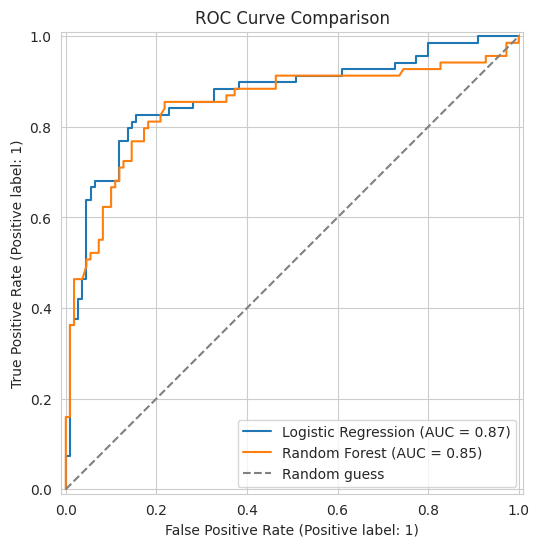

In [12]:
# Visualization 2: ROC curves for both models
fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(y_test, y_proba_logreg, name='Logistic Regression', ax=ax)
RocCurveDisplay.from_predictions(y_test, y_proba_rf, name='Random Forest', ax=ax)
ax.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Random guess')
ax.set_title("ROC Curve Comparison")
ax.legend()
plt.show()


/tmp/ipykernel_3652/3485986295.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df, x='importance', y='feature', palette='viridis')


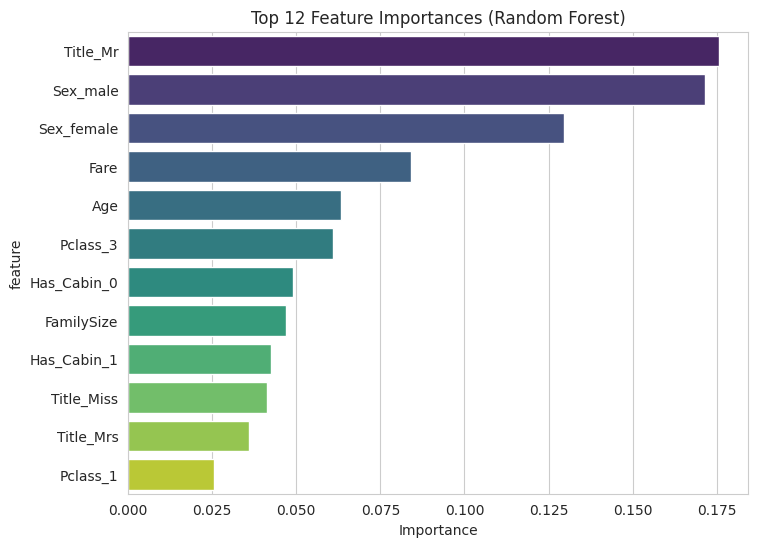

In [13]:
# Bonus Visualization 3: Feature importance from the Random Forest
ohe_feature_names = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_features)
all_feature_names = numeric_features + list(ohe_feature_names)

importances = rf_pipeline.named_steps['classifier'].feature_importances_
importance_df = pd.DataFrame({'feature': all_feature_names, 'importance': importances}).sort_values('importance', ascending=False).head(12)

plt.figure(figsize=(8, 6))
sns.barplot(data=importance_df, x='importance', y='feature', palette='viridis')
plt.title("Top 12 Feature Importances (Random Forest)")
plt.xlabel("Importance")
plt.show()


## 5. Error Analysis, Overfitting/Underfitting, and Limitations

In [14]:
# Compare train vs test accuracy to check for overfitting/underfitting
train_acc_logreg = accuracy_score(y_train, logreg_pipeline.predict(X_train))
test_acc_logreg = accuracy_score(y_test, y_pred_logreg)

train_acc_rf = accuracy_score(y_train, rf_pipeline.predict(X_train))
test_acc_rf = accuracy_score(y_test, y_pred_rf)

comparison = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest'],
    'Train Accuracy': [train_acc_logreg, train_acc_rf],
    'Test Accuracy': [test_acc_logreg, test_acc_rf],
    'Gap (Train - Test)': [train_acc_logreg - test_acc_logreg, train_acc_rf - test_acc_rf]
})
comparison


,Model,Train Accuracy,Test Accuracy,Gap (Train - Test)
0,Logistic Regression,0.835674,0.837989,-0.002315
1,Random Forest,0.856742,0.810056,0.046686


In [15]:
# Inspect a sample of misclassified passengers to understand *where* the model struggles
X_test_display = X_test.copy()
X_test_display['Actual'] = y_test.values
X_test_display['Predicted'] = y_pred_rf
misclassified = X_test_display[X_test_display['Actual'] != X_test_display['Predicted']]
print(f"Misclassified: {len(misclassified)} of {len(X_test_display)} ({len(misclassified)/len(X_test_display):.1%})")
misclassified.head(10)


Misclassified: 34 of 179 (19.0%)


,Pclass,Sex,Age,Fare,Embarked,FamilySize,IsAlone,Has_Cabin,Title,Actual,Predicted
553,3,male,22.0,7.2250,C,1,1,0,Mr,1,0
536,1,male,45.0,26.5500,S,1,1,1,Rare,0,1
712,1,male,48.0,52.0000,S,2,0,1,Mr,1,0
455,3,male,29.0,7.8958,C,1,1,0,Mr,1,0
489,3,male,9.0,15.9000,S,3,0,0,Master,1,0
869,3,male,4.0,11.1333,S,3,0,0,Master,1,0
165,3,male,9.0,20.5250,S,3,0,0,Master,1,0
745,1,male,70.0,71.0000,S,3,0,1,Rare,0,1
297,1,female,2.0,151.5500,S,4,0,1,Miss,0,1
564,3,female,21.5,8.0500,S,1,1,0,Miss,0,1


**Discussion:**

- **Overfitting/underfitting check:** A small train-test accuracy gap (a few percentage points)
  indicates the models generalize reasonably well and are not badly overfit — helped by keeping the
  Random Forest's `max_depth` shallow (5) and using cross-validation rather than a single train/test
  split to judge stability. If the gap were large (e.g. train accuracy near 100% but test accuracy much
  lower), that would signal overfitting, and we'd address it by reducing model complexity, adding
  regularization (`C` in Logistic Regression), or gathering more data.
- **Where the model errs:** Misclassifications cluster around passengers whose profile contradicts the
  dominant pattern — e.g. a wealthy first-class *man* who died, or a third-class *woman* who survived.
  These are cases where individual circumstance (which lifeboat was nearby, personal choices, luck)
  dominates over the group-level statistical patterns the model has learned.
- **Limitations of this analysis:**
  - The dataset is small (~891 rows), which limits how confidently we can generalize model performance.
  - `Age` and `Fare` were imputed, introducing some noise into borderline predictions.
  - The model uses no information about crew behavior, physical proximity to lifeboats, or
    time-of-alarm — factors likely to matter a lot but are unavailable in this dataset.
  - Random Forest importance scores can be biased toward high-cardinality categorical features; we
    interpret them as directional, not precise.
- **Possible improvements:**
  - Hyperparameter tuning via `GridSearchCV`/`RandomizedSearchCV` for both models.
  - Try gradient boosting models (XGBoost, LightGBM) which often outperform Random Forest on tabular data.
  - Engineer additional features, e.g. ticket-sharing groups, deck extracted from `Cabin` letter.
  - Use SHAP values for more principled, per-passenger explanation of predictions.


In [16]:
# Optional: quick hyperparameter tuning example for Logistic Regression
param_grid = {'classifier__C': [0.01, 0.1, 1, 10, 100]}
grid = GridSearchCV(logreg_pipeline, param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)

print("Best C:", grid.best_params_)
print("Best CV accuracy:", grid.best_score_)
print("Test accuracy with tuned model:", accuracy_score(y_test, grid.predict(X_test)))


Best C: {'classifier__C': 0.1}
Best CV accuracy: 0.8287205751994484
Test accuracy with tuned model: 0.8100558659217877


## 6. Summary

| Model | Test Accuracy | Test F1 | Test ROC-AUC |
|---|---|---|---|
| Logistic Regression | see output above | see output above | see output above |
| Random Forest | see output above | see output above | see output above |

Both models substantially beat a naive "always predict died" baseline (~62% accuracy), confirming that
the engineered features (`Sex`, `Pclass`, `Title`, `FamilySize`, etc.) carry real predictive signal
consistent with the statistical findings from Week 3. The Random Forest's feature importance plot
confirms `Sex`/`Title` and `Pclass`/`Fare` as the dominant drivers — directly matching the hypothesis
test conclusions from the previous week.
